<a href="https://www.kaggle.com/code/lalit7881/new-york-sold-real-estate-intelligence-2026-eda?scriptVersionId=324382945" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kanchana1990/new-york-sold-real-estate-intelligence-2026/ny_real_estate_sold_properties_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/new-york-sold-real-estate-intelligence-2026/ny_real_estate_sold_properties_2026.csv")

In [3]:
df.head()

,type,sub_type,text,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,...,city,sold_list_ratio,price_per_sqft_sold,price_per_sqft_list,sold_vs_asking,total_baths,has_garage,has_list_price,size_tier,sqft_available
0,multi_family,NaN,SOLD before print,157500.0,157500,2132.0,NaN,4.0,2.0,2.0,...,Troy,1.0000,73.87,73.87,At Asking,2.0,0,1,Large (2000-3500),1
1,single_family,NaN,Sold Before Print,205000.0,205000,1946.0,NaN,4.0,4.0,3.0,...,Rotterdam,1.0000,105.34,105.34,At Asking,3.0,1,1,Mid (1250-2000),1
2,single_family,NaN,An opportunity to own a piece of property with...,329000.0,305000,2637.0,2.0,4.0,3.0,3.0,...,Saranac Lake,0.9271,115.66,124.76,Below Asking,3.0,1,1,Large (2000-3500),1
3,single_family,NaN,Beautiful setting on 8 acres in Vermontville. ...,285000.0,290000,1800.0,2.0,4.0,2.0,1.0,...,Vermontville,1.0175,161.11,158.33,Above Asking,1.0,0,1,Mid (1250-2000),1
4,single_family,NaN,"**Auction Property, the online sales event for...",1.0,74552,1404.0,NaN,3.0,1.0,1.0,...,Pottersville,74552.0000,53.10,0.00,Above Asking,1.0,0,1,Mid (1250-2000),1


In [4]:
df.tail()

,type,sub_type,text,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,...,city,sold_list_ratio,price_per_sqft_sold,price_per_sqft_list,sold_vs_asking,total_baths,has_garage,has_list_price,size_tier,sqft_available
10249,coop,co_op,JUST LISTED - Turn-Key Renovated One-Bedroom o...,550000.0,525000,NaN,15.0,1.0,NaN,NaN,...,New York,0.9545,NaN,NaN,Below Asking,0.0,0,1,NaN,0
10250,coop,co_op,"Bright and cozy 1-bedroom, 1-bathroom unit in ...",229999.0,230000,710.0,NaN,1.0,1.0,1.0,...,Oakland Gardens,1.0000,323.94,323.94,At Asking,1.0,0,1,Micro (<750),1
10251,coop,co_op,"This move-in-ready, well-maintained 1-bedroom ...",244900.0,250000,820.0,1.0,1.0,1.0,1.0,...,Selden,1.0208,304.88,298.66,Above Asking,1.0,0,1,Small (750-1250),1
10252,other,NaN,NaN,NaN,900000,4240.0,2.0,7.0,2.0,2.0,...,Marlboro,NaN,212.26,NaN,No List Price,2.0,0,0,Luxury (3500+),1
10253,coop,co_op,Nestled within one of Chelsea's most distingui...,1675000.0,1675000,NaN,20.0,2.0,NaN,NaN,...,New York,1.0000,NaN,NaN,At Asking,0.0,0,1,NaN,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10254 entries, 0 to 10253
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 10254 non-null  object 
 1   sub_type             1142 non-null   object 
 2   text                 7286 non-null   object 
 3   listPrice            7345 non-null   float64
 4   lastSoldPrice        10254 non-null  int64  
 5   sqft                 9988 non-null   float64
 6   stories              7083 non-null   float64
 7   beds                 8582 non-null   float64
 8   baths                9996 non-null   float64
 9   baths_full           8605 non-null   float64
 10  baths_full_calc      8613 non-null   float64
 11  garage               5020 non-null   float64
 12  zip_code             10254 non-null  float64
 13  city                 10254 non-null  object 
 14  sold_list_ratio      7345 non-null   float64
 15  price_per_sqft_sold  9989 non-null  

In [6]:
df.describe()

,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,zip_code,sold_list_ratio,price_per_sqft_sold,price_per_sqft_list,total_baths,has_garage,has_list_price,sqft_available
count,7.345000e+03,1.025400e+04,9988.000000,7083.000000,8582.000000,9996.000000,8605.000000,8613.000000,5020.000000,10254.000000,7345.000000,9989.000000,7092.000000,10254.000000,10254.000000,10254.000000,10254.000000
mean,6.161016e+05,7.654686e+05,1915.298358,3.477340,3.350734,1.955182,1.845322,1.875189,1.667331,12385.093427,116.779699,448.045950,376.993057,1.552077,0.489565,0.716306,0.974059
std,9.589015e+05,1.231452e+06,1538.521214,7.231371,1.308506,1.303166,0.953298,1.002020,0.965890,1422.761881,6392.334586,3528.170117,4135.535543,1.113902,0.499915,0.450812,0.158967
min,1.000000e+00,1.000000e+04,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,10001.000000,0.122500,1.600000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.299000e+05,2.580000e+05,1224.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,11354.000000,0.964900,167.840000,150.472500,1.000000,0.000000,0.000000,1.000000
50%,3.890000e+05,4.799000e+05,1624.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,12118.000000,1.000000,277.520000,230.190000,2.000000,0.000000,1.000000,1.000000
75%,7.100000e+05,8.500000e+05,2212.000000,2.000000,4.000000,3.000000,2.000000,2.000000,2.000000,13648.000000,1.063700,499.320000,416.105000,2.000000,1.000000,1.000000,1.000000
max,3.500000e+07,4.333300e+07,36795.000000,98.000000,16.000000,16.000000,24.000000,24.000000,40.000000,18848.000000,514800.000000,350000.000000,347500.000000,24.000000,1.000000,1.000000,1.000000


In [7]:
df.isnull()

,type,sub_type,text,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,...,city,sold_list_ratio,price_per_sqft_sold,price_per_sqft_list,sold_vs_asking,total_baths,has_garage,has_list_price,size_tier,sqft_available
0,False,True,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10249,False,False,False,False,False,True,False,False,True,True,...,False,False,True,True,False,False,False,False,True,False
10250,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10251,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10252,False,True,True,True,False,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False


In [8]:
df.isnull().sum()

type                      0
sub_type               9112
text                   2968
listPrice              2909
lastSoldPrice             0
sqft                    266
stories                3171
beds                   1672
baths                   258
baths_full             1649
baths_full_calc        1641
garage                 5234
zip_code                  0
city                      0
sold_list_ratio        2909
price_per_sqft_sold     265
price_per_sqft_list    3162
sold_vs_asking            0
total_baths               0
has_garage                0
has_list_price            0
size_tier               265
sqft_available            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

type                    object
sub_type                object
text                    object
listPrice              float64
lastSoldPrice            int64
sqft                   float64
stories                float64
beds                   float64
baths                  float64
baths_full             float64
baths_full_calc        float64
garage                 float64
zip_code               float64
city                    object
sold_list_ratio        float64
price_per_sqft_sold    float64
price_per_sqft_list    float64
sold_vs_asking          object
total_baths            float64
has_garage               int64
has_list_price           int64
size_tier               object
sqft_available           int64
dtype: object

In [11]:
df.shape

(10254, 23)

In [12]:
df.columns

Index(['type', 'sub_type', 'text', 'listPrice', 'lastSoldPrice', 'sqft',
       'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage',
       'zip_code', 'city', 'sold_list_ratio', 'price_per_sqft_sold',
       'price_per_sqft_list', 'sold_vs_asking', 'total_baths', 'has_garage',
       'has_list_price', 'size_tier', 'sqft_available'],
      dtype='object')

In [13]:
df.nunique()

type                      7
sub_type                  3
text                   7245
listPrice              1406
lastSoldPrice          2297
sqft                   2794
stories                  64
beds                     14
baths                    15
baths_full               11
baths_full_calc          12
garage                   12
zip_code               1262
city                   1093
sold_list_ratio        2789
price_per_sqft_sold    8731
price_per_sqft_list    6382
sold_vs_asking            4
total_baths              13
has_garage                2
has_list_price            2
size_tier                 5
sqft_available            2
dtype: int64

## EDA

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

# Plot style
plt.style.use('ggplot')

# Color palettes
palette1 = "viridis"
palette2 = "coolwarm"
palette3 = "Set2"
palette4 = "magma"
palette5 = "tab20"

sns.set_theme(style="whitegrid")

In [15]:
print(df.shape)

display(df.head())

display(df.info())

display(df.describe(include='all'))

(10254, 23)


,type,sub_type,text,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,...,city,sold_list_ratio,price_per_sqft_sold,price_per_sqft_list,sold_vs_asking,total_baths,has_garage,has_list_price,size_tier,sqft_available
0,multi_family,NaN,SOLD before print,157500.0,157500,2132.0,NaN,4.0,2.0,2.0,...,Troy,1.0000,73.87,73.87,At Asking,2.0,0,1,Large (2000-3500),1
1,single_family,NaN,Sold Before Print,205000.0,205000,1946.0,NaN,4.0,4.0,3.0,...,Rotterdam,1.0000,105.34,105.34,At Asking,3.0,1,1,Mid (1250-2000),1
2,single_family,NaN,An opportunity to own a piece of property with...,329000.0,305000,2637.0,2.0,4.0,3.0,3.0,...,Saranac Lake,0.9271,115.66,124.76,Below Asking,3.0,1,1,Large (2000-3500),1
3,single_family,NaN,Beautiful setting on 8 acres in Vermontville. ...,285000.0,290000,1800.0,2.0,4.0,2.0,1.0,...,Vermontville,1.0175,161.11,158.33,Above Asking,1.0,0,1,Mid (1250-2000),1
4,single_family,NaN,"**Auction Property, the online sales event for...",1.0,74552,1404.0,NaN,3.0,1.0,1.0,...,Pottersville,74552.0000,53.10,0.00,Above Asking,1.0,0,1,Mid (1250-2000),1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10254 entries, 0 to 10253
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 10254 non-null  object 
 1   sub_type             1142 non-null   object 
 2   text                 7286 non-null   object 
 3   listPrice            7345 non-null   float64
 4   lastSoldPrice        10254 non-null  int64  
 5   sqft                 9988 non-null   float64
 6   stories              7083 non-null   float64
 7   beds                 8582 non-null   float64
 8   baths                9996 non-null   float64
 9   baths_full           8605 non-null   float64
 10  baths_full_calc      8613 non-null   float64
 11  garage               5020 non-null   float64
 12  zip_code             10254 non-null  float64
 13  city                 10254 non-null  object 
 14  sold_list_ratio      7345 non-null   float64
 15  price_per_sqft_sold  9989 non-null  

None

,type,sub_type,text,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,...,city,sold_list_ratio,price_per_sqft_sold,price_per_sqft_list,sold_vs_asking,total_baths,has_garage,has_list_price,size_tier,sqft_available
count,10254,1142,7286,7.345000e+03,1.025400e+04,9988.000000,7083.000000,8582.000000,9996.000000,8605.000000,...,10254,7345.000000,9989.000000,7092.000000,10254,10254.000000,10254.000000,10254.000000,9989,10254.000000
unique,7,3,7245,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1093,NaN,NaN,NaN,4,NaN,NaN,NaN,5,NaN
top,single_family,condo,Sold before print,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Brooklyn,NaN,NaN,NaN,Above Asking,NaN,NaN,NaN,Mid (1250-2000),NaN
freq,6946,649,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,655,NaN,NaN,NaN,3117,NaN,NaN,NaN,4081,NaN
mean,NaN,NaN,NaN,6.161016e+05,7.654686e+05,1915.298358,3.477340,3.350734,1.955182,1.845322,...,NaN,116.779699,448.045950,376.993057,NaN,1.552077,0.489565,0.716306,NaN,0.974059
std,NaN,NaN,NaN,9.589015e+05,1.231452e+06,1538.521214,7.231371,1.308506,1.303166,0.953298,...,NaN,6392.334586,3528.170117,4135.535543,NaN,1.113902,0.499915,0.450812,NaN,0.158967
min,NaN,NaN,NaN,1.000000e+00,1.000000e+04,2.000000,0.000000,0.000000,0.000000,1.000000,...,NaN,0.122500,1.600000,0.000000,NaN,0.000000,0.000000,0.000000,NaN,0.000000
25%,NaN,NaN,NaN,2.299000e+05,2.580000e+05,1224.000000,1.000000,3.000000,1.000000,1.000000,...,NaN,0.964900,167.840000,150.472500,NaN,1.000000,0.000000,0.000000,NaN,1.000000
50%,NaN,NaN,NaN,3.890000e+05,4.799000e+05,1624.000000,2.000000,3.000000,2.000000,2.000000,...,NaN,1.000000,277.520000,230.190000,NaN,2.000000,0.000000,1.000000,NaN,1.000000
75%,NaN,NaN,NaN,7.100000e+05,8.500000e+05,2212.000000,2.000000,4.000000,3.000000,2.000000,...,NaN,1.063700,499.320000,416.105000,NaN,2.000000,1.000000,1.000000,NaN,1.000000


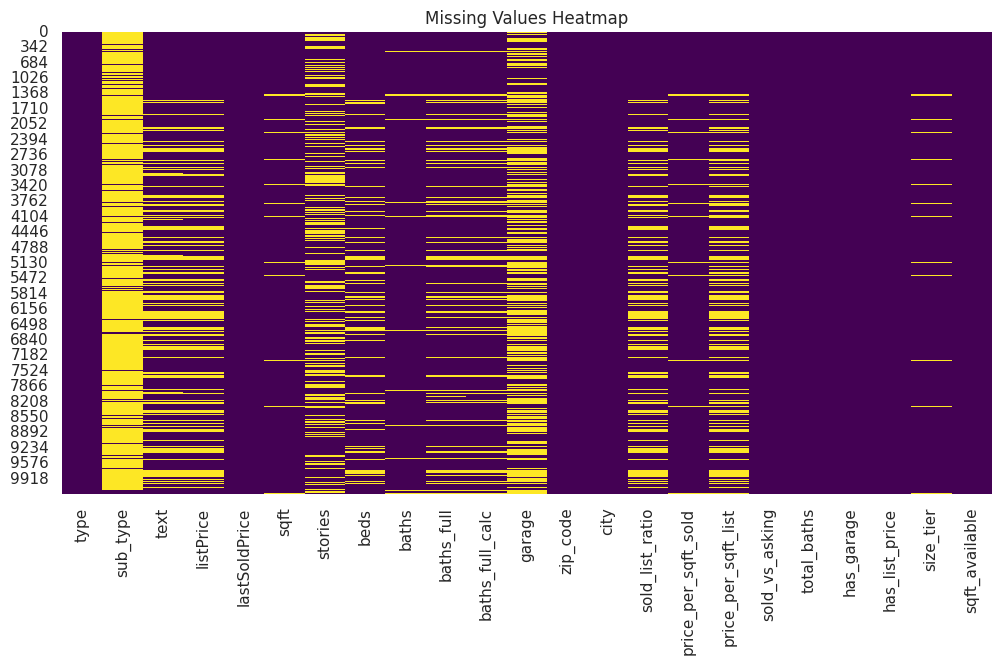

In [16]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")
plt.show()

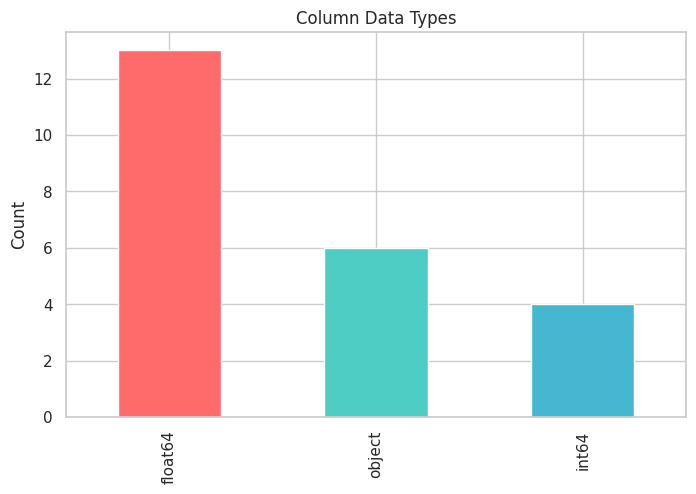

In [17]:
dtype_counts = df.dtypes.value_counts()

plt.figure(figsize=(8,5))

dtype_counts.plot(
    kind='bar',
    color=['#FF6B6B','#4ECDC4','#45B7D1']
)

plt.title("Column Data Types")
plt.ylabel("Count")
plt.show()

In [18]:
numerical_cols = [
    'listPrice',
    'lastSoldPrice',
    'sqft',
    'stories',
    'beds',
    'baths',
    'garage',
    'sold_list_ratio',
    'price_per_sqft_sold',
    'price_per_sqft_list',
    'sold_vs_asking',
    'total_baths'
]

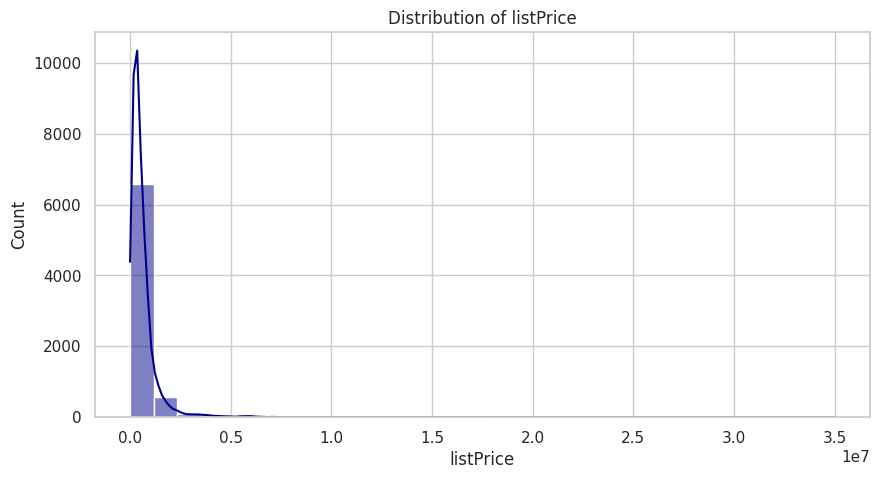

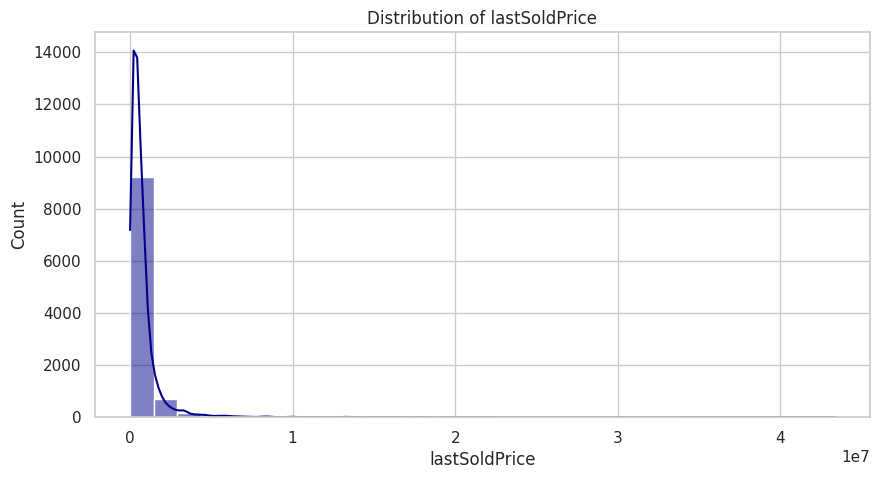

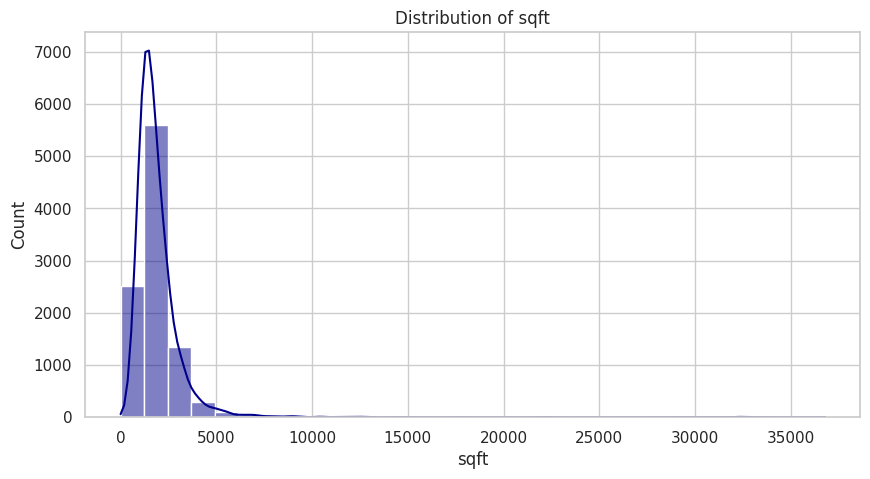

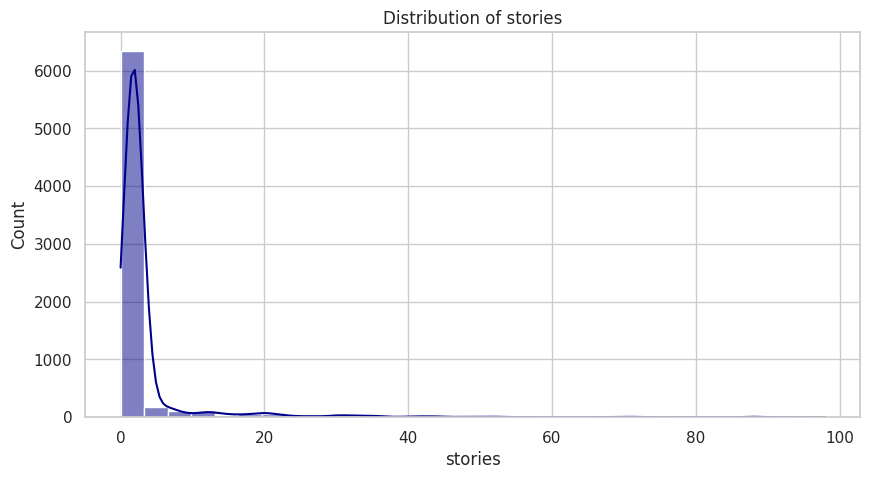

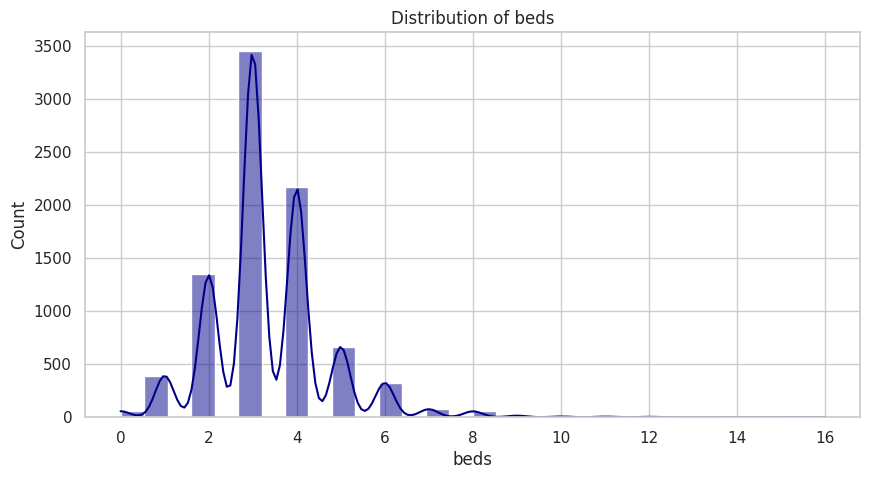

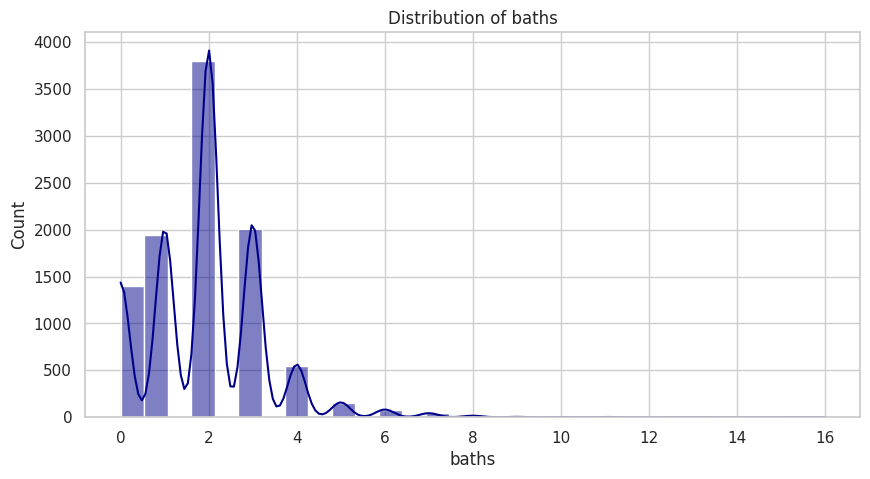

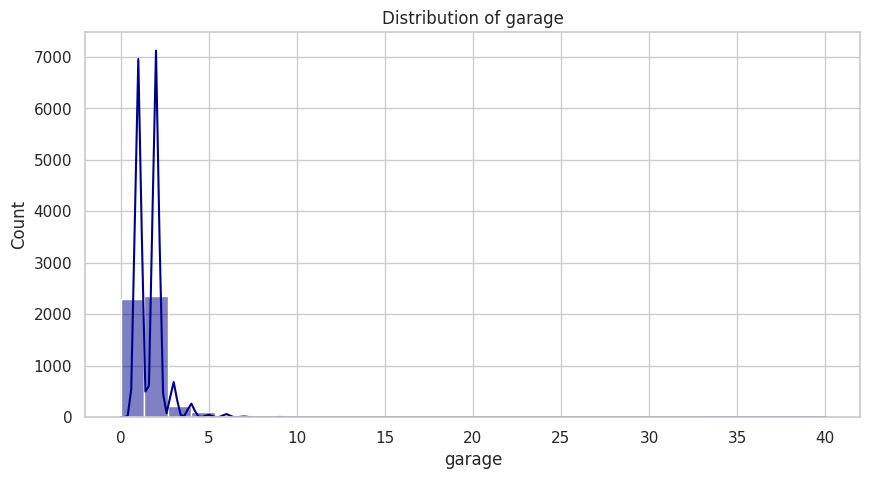

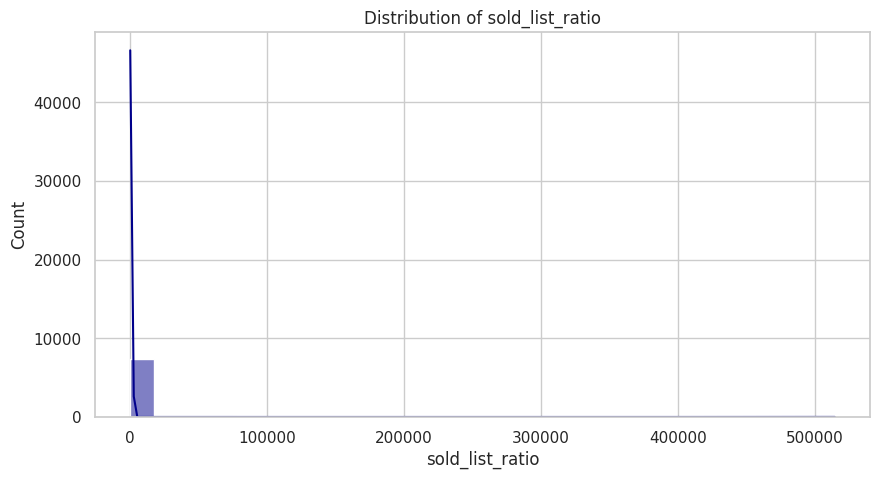

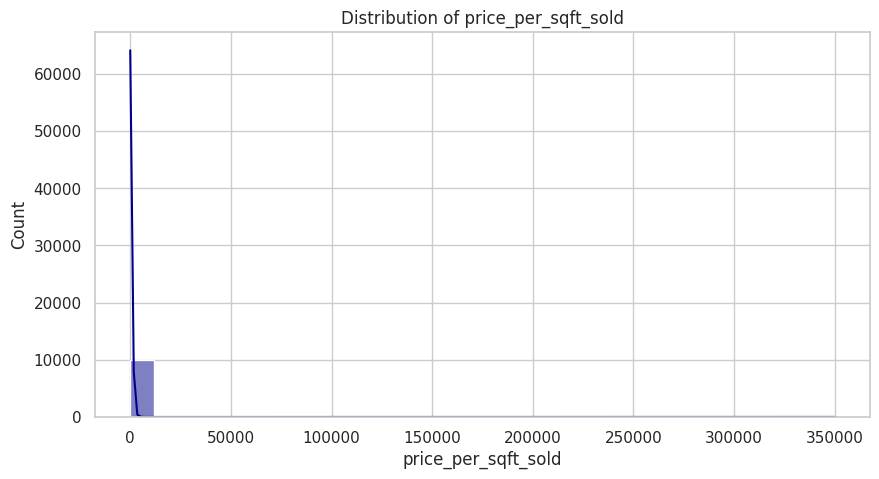

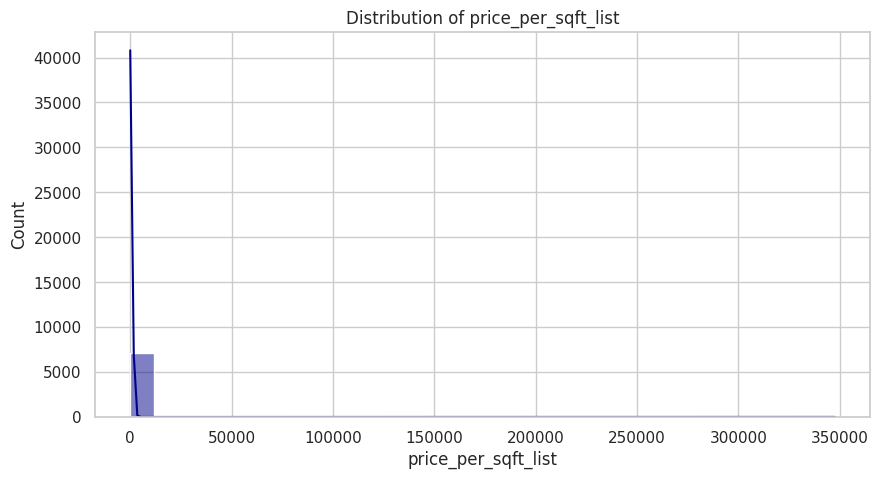

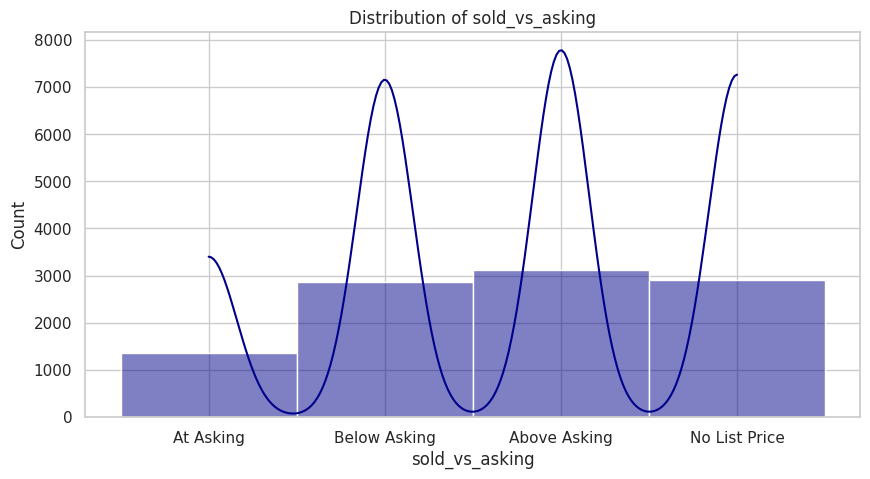

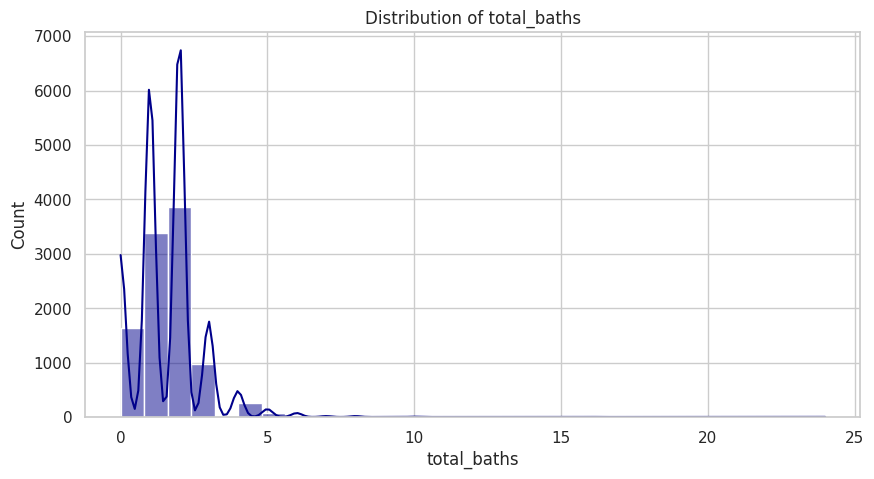

In [19]:
for col in numerical_cols:

    plt.figure(figsize=(10,5))

    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        color='darkblue'
    )

    plt.title(f"Distribution of {col}")
    plt.show()

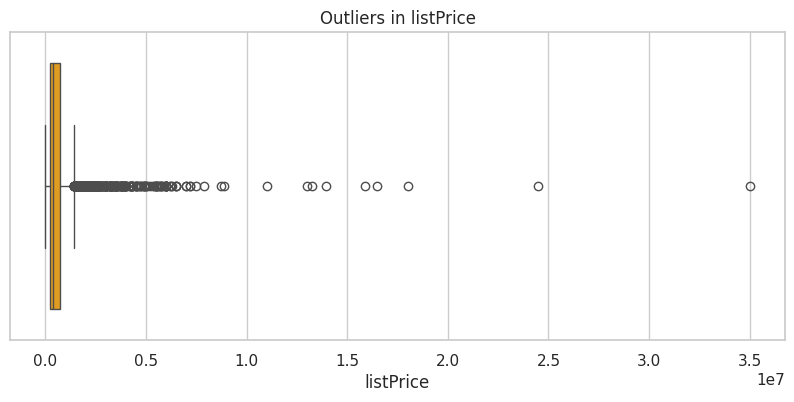

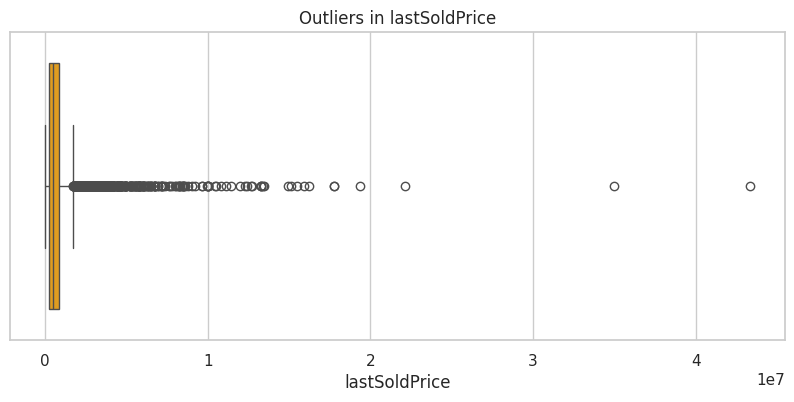

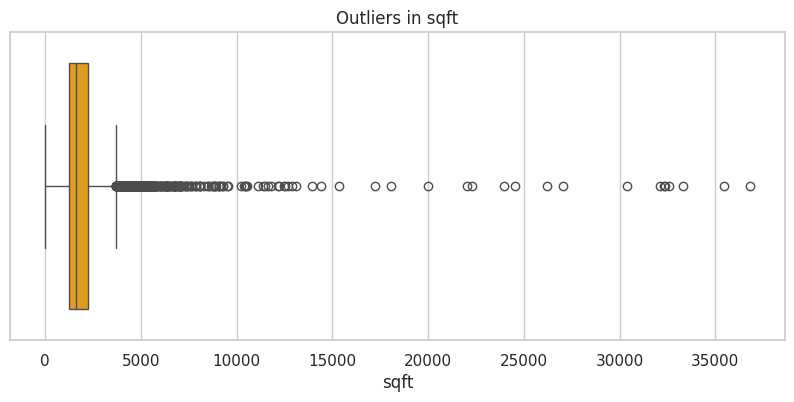

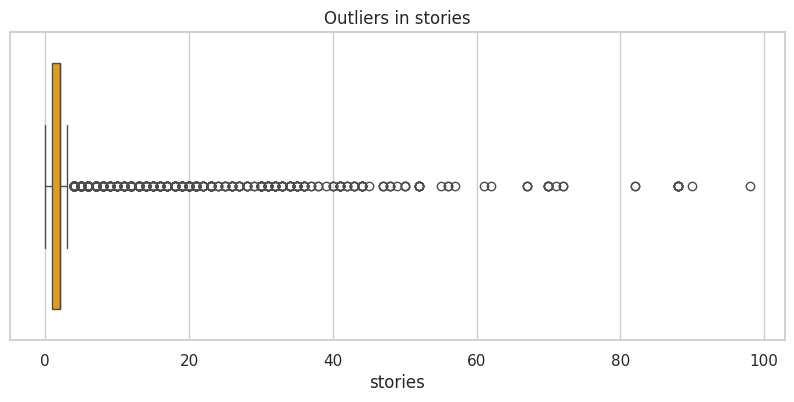

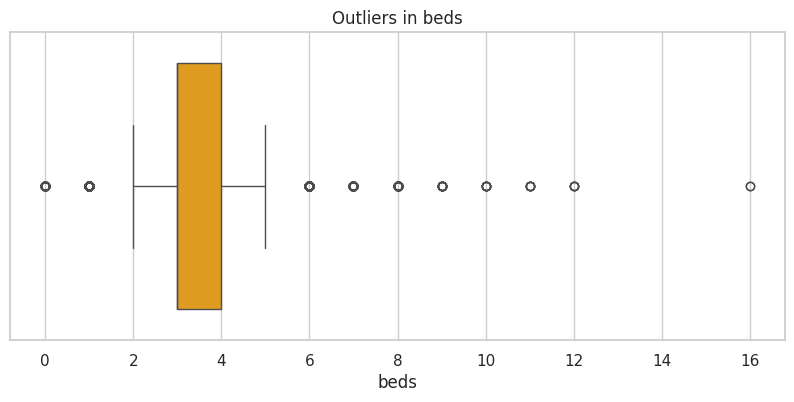

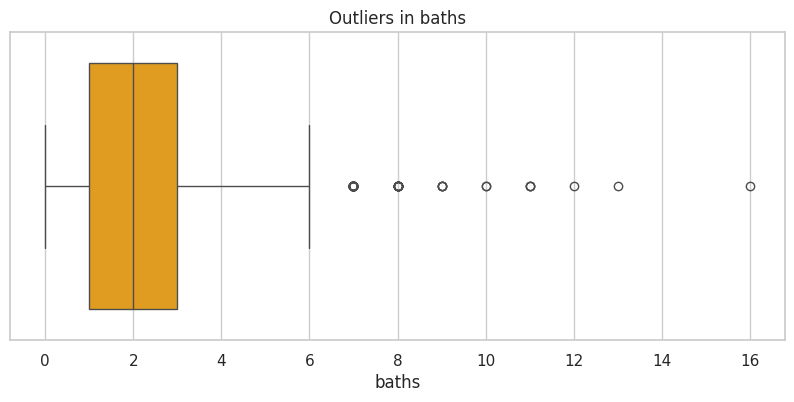

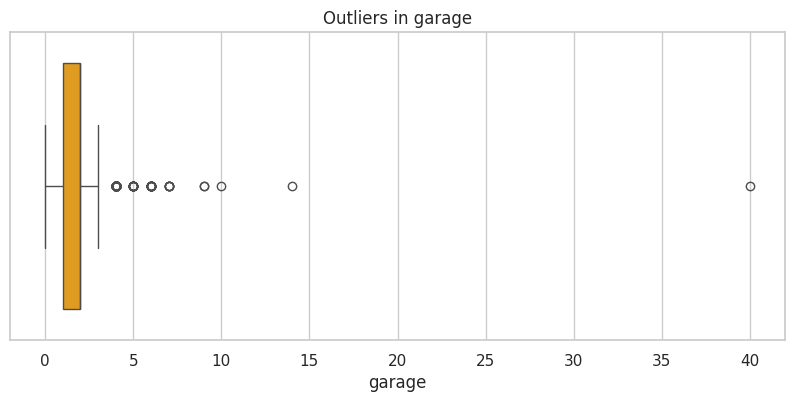

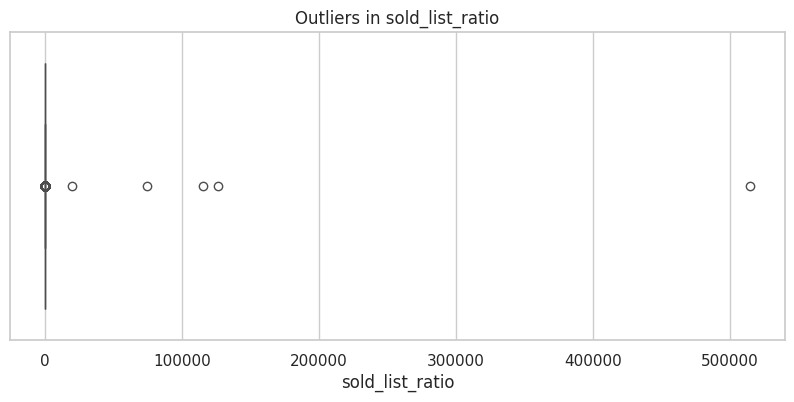

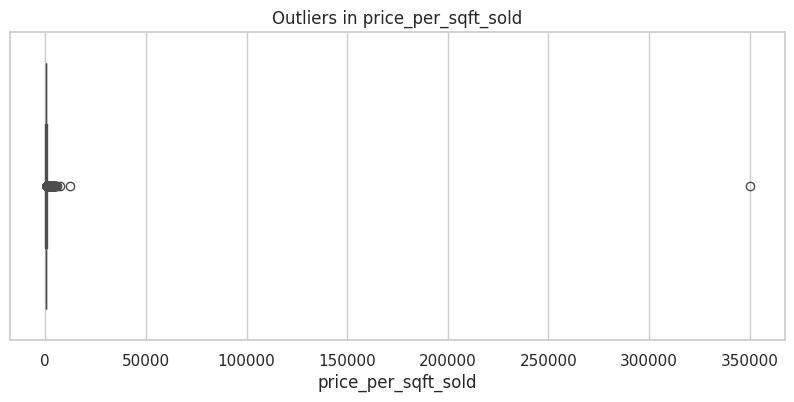

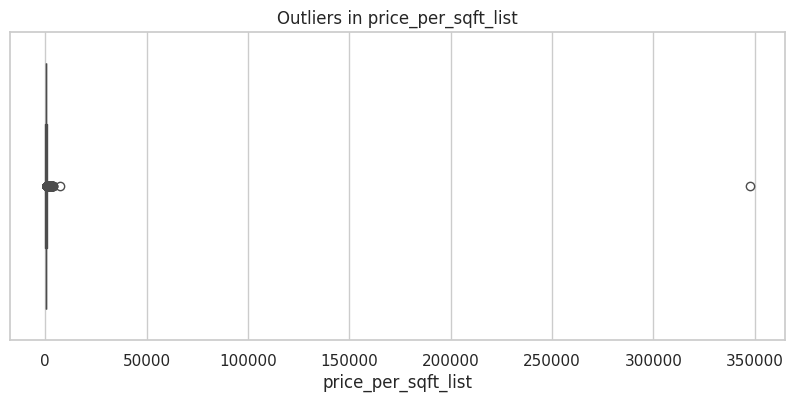

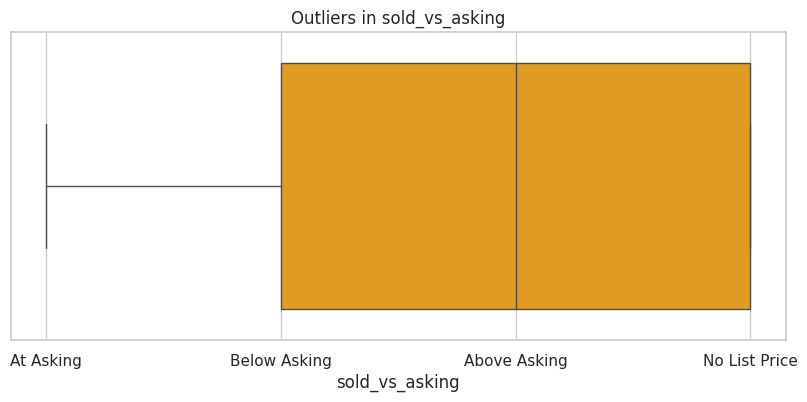

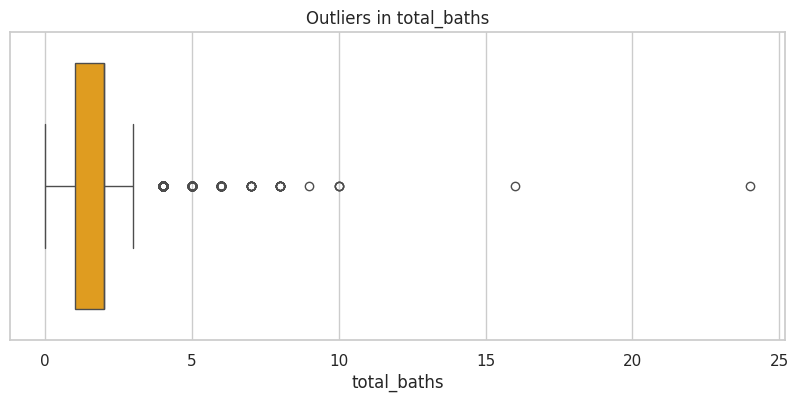

In [20]:
for col in numerical_cols:

    plt.figure(figsize=(10,4))

    sns.boxplot(
        x=df[col],
        color='orange'
    )

    plt.title(f"Outliers in {col}")
    plt.show()

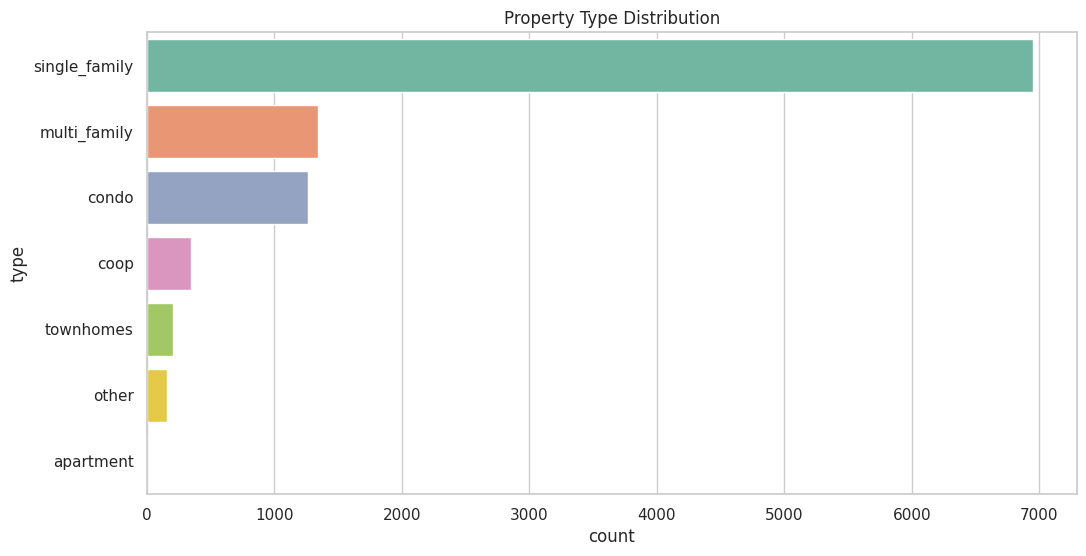

In [21]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='type',
    palette='Set2',
    order=df['type'].value_counts().index
)

plt.title("Property Type Distribution")
plt.show()

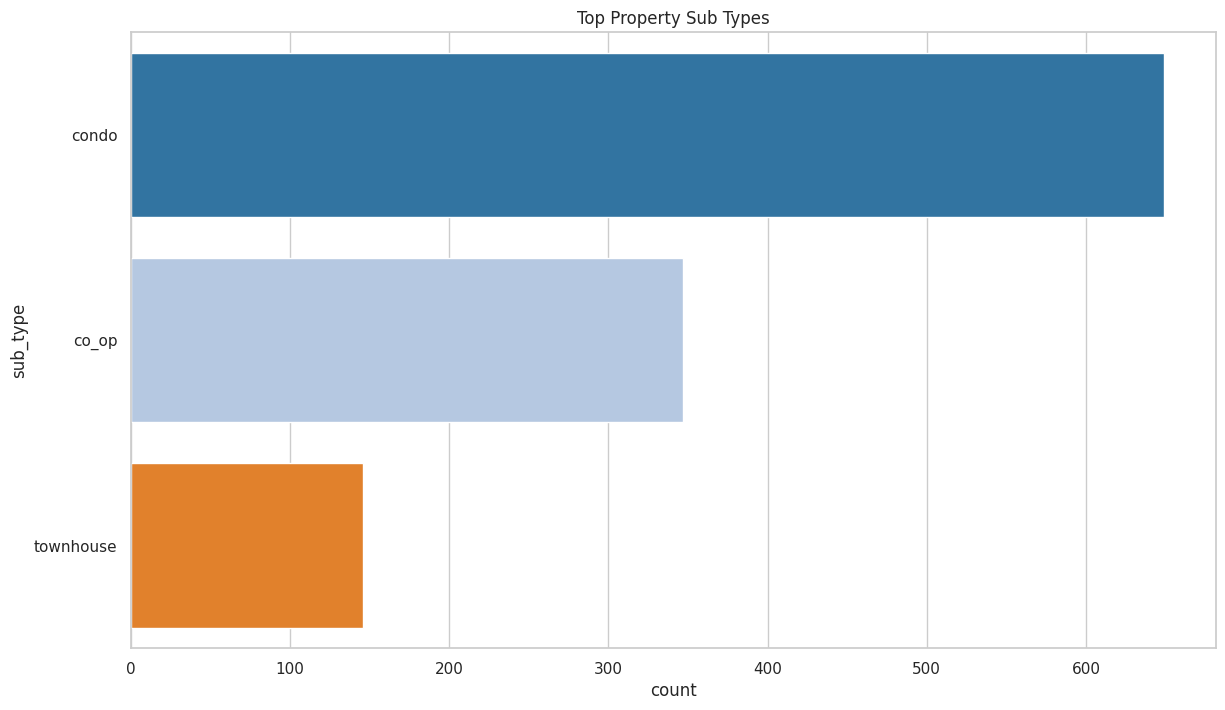

In [22]:
plt.figure(figsize=(14,8))

sns.countplot(
    data=df,
    y='sub_type',
    palette='tab20',
    order=df['sub_type'].value_counts().head(15).index
)

plt.title("Top Property Sub Types")
plt.show()

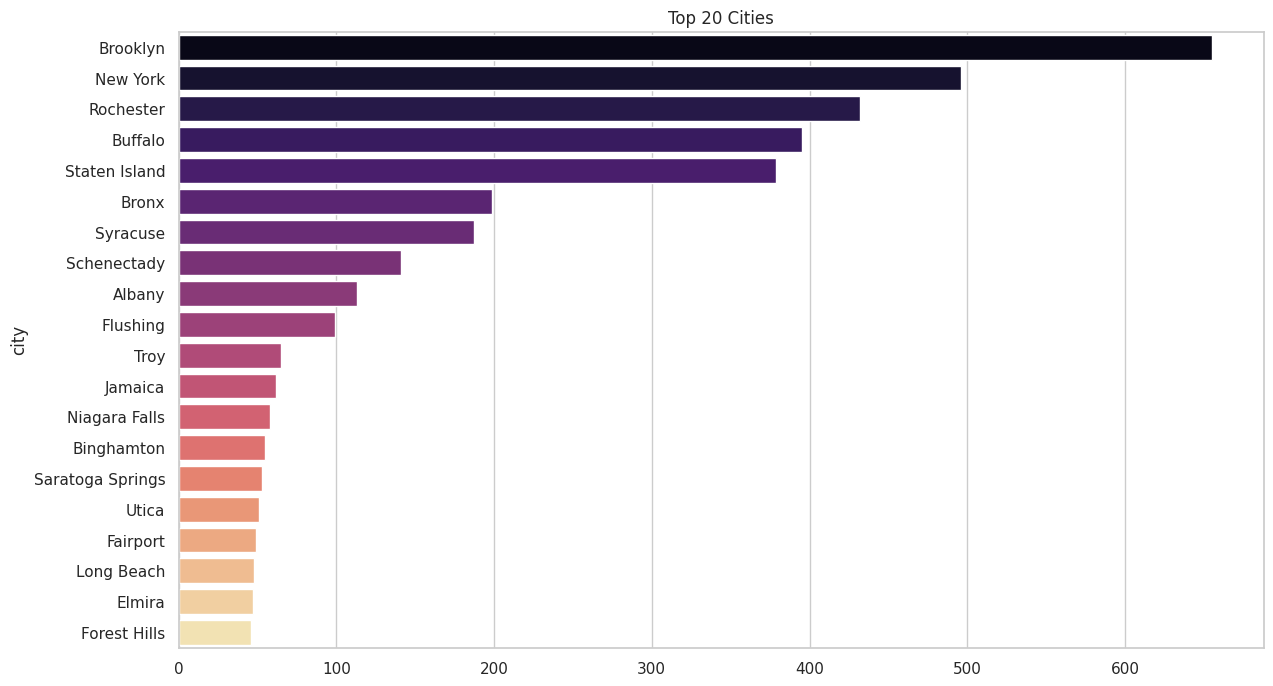

In [23]:
top_cities = df['city'].value_counts().head(20)

plt.figure(figsize=(14,8))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index,
    palette='magma'
)

plt.title("Top 20 Cities")
plt.show()

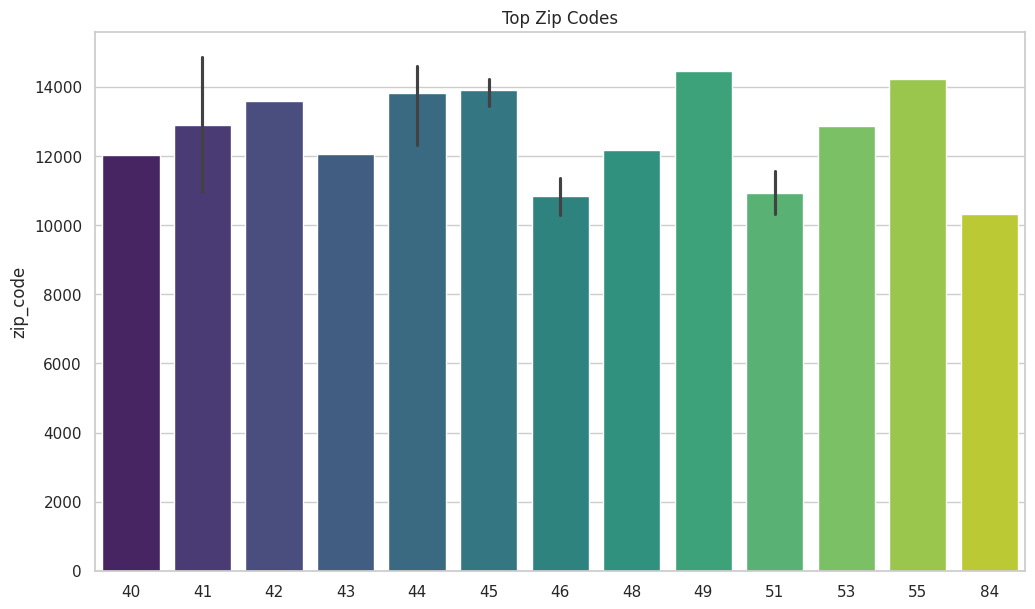

In [24]:
top_zip = df['zip_code'].value_counts().head(20)

plt.figure(figsize=(12,7))

sns.barplot(
    x=top_zip.values,
    y=top_zip.index,
    palette='viridis'
)

plt.title("Top Zip Codes")
plt.show()

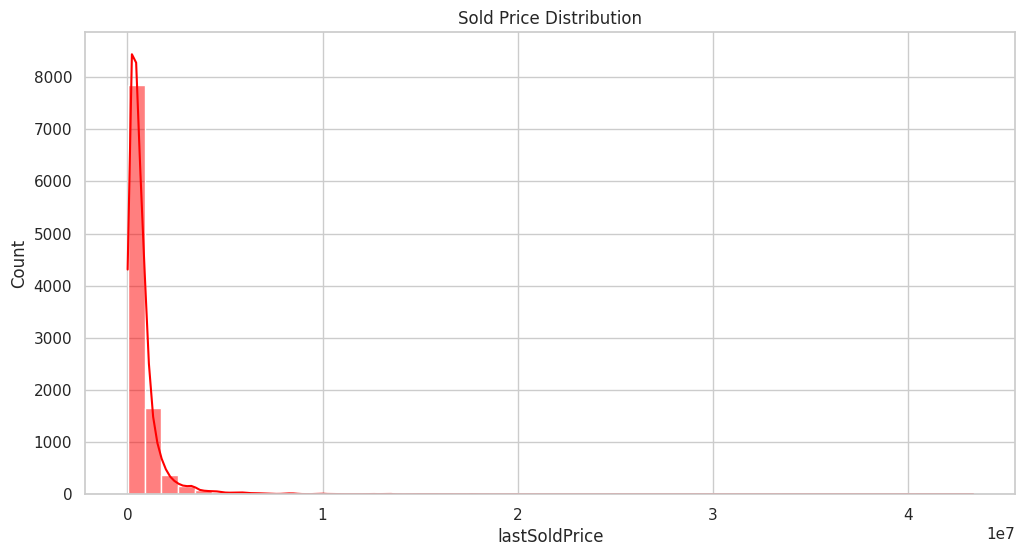

In [25]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['lastSoldPrice'],
    bins=50,
    kde=True,
    color='red'
)

plt.title("Sold Price Distribution")
plt.show()

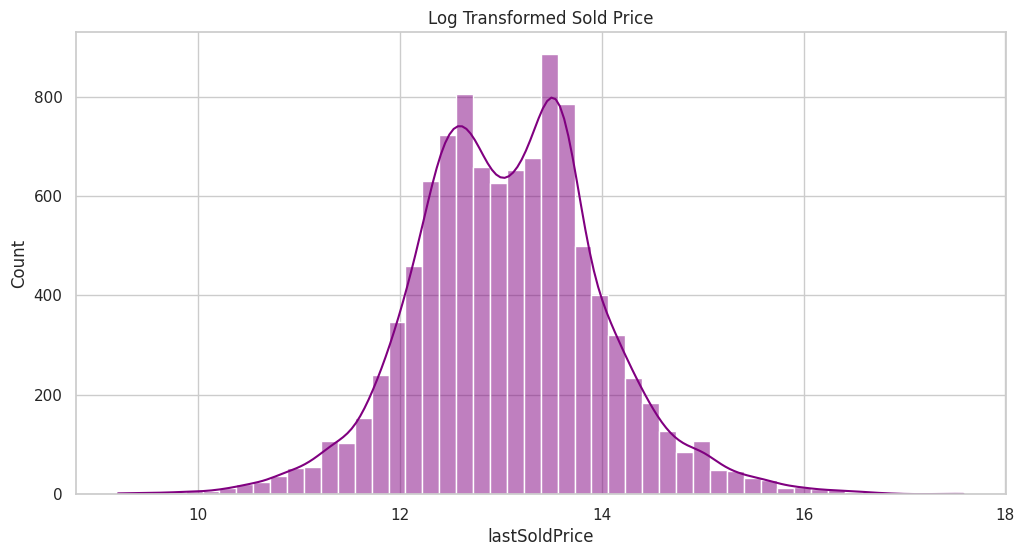

In [26]:
plt.figure(figsize=(12,6))

sns.histplot(
    np.log1p(df['lastSoldPrice']),
    bins=50,
    kde=True,
    color='purple'
)

plt.title("Log Transformed Sold Price")
plt.show()

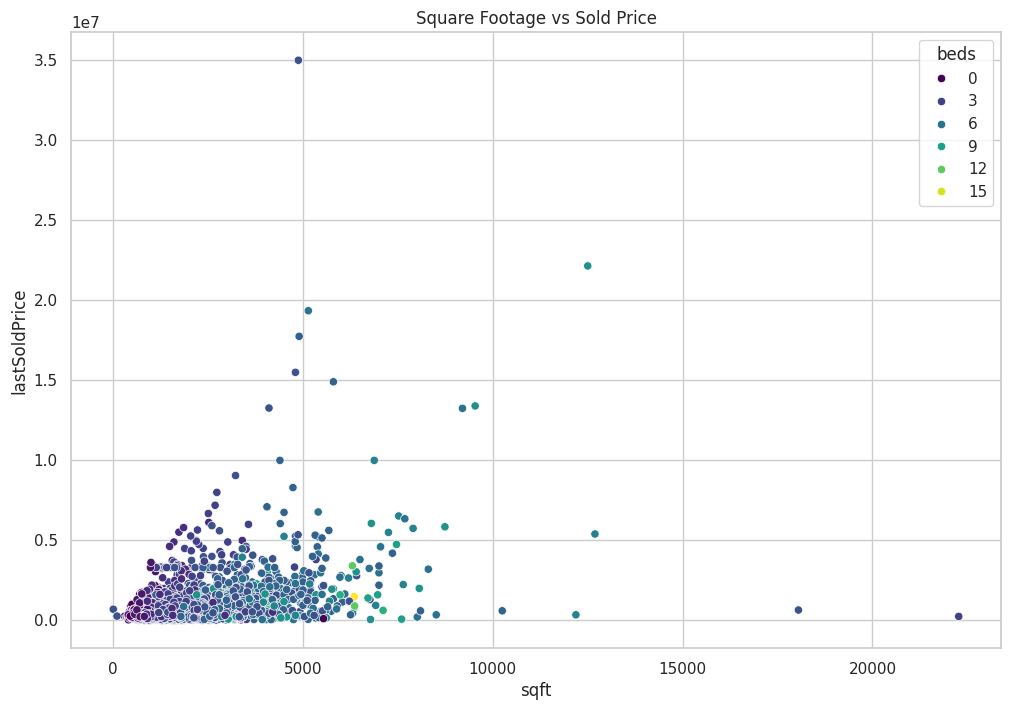

In [27]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='sqft',
    y='lastSoldPrice',
    hue='beds',
    palette='viridis'
)

plt.title("Square Footage vs Sold Price")
plt.show()

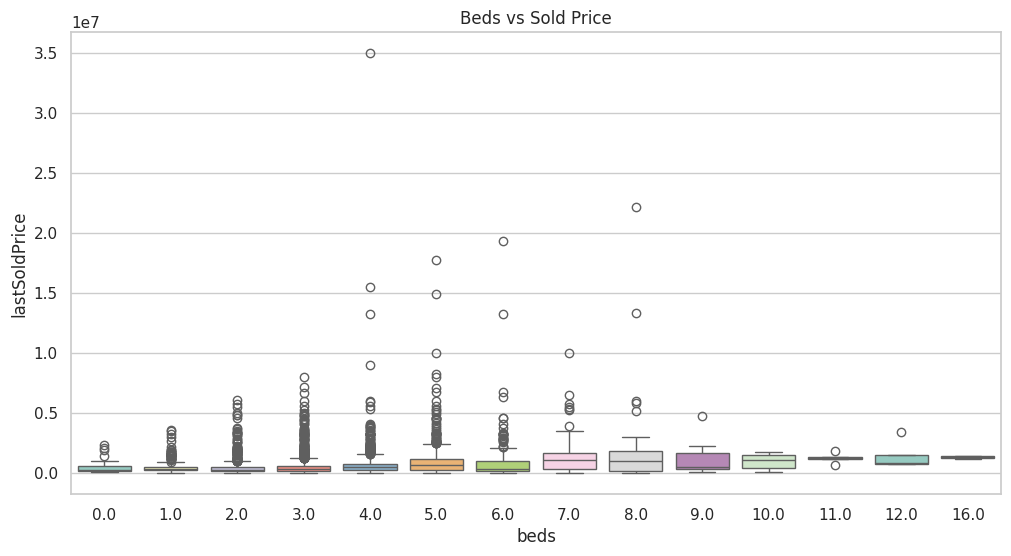

In [28]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='beds',
    y='lastSoldPrice',
    palette='Set3'
)

plt.title("Beds vs Sold Price")
plt.show()

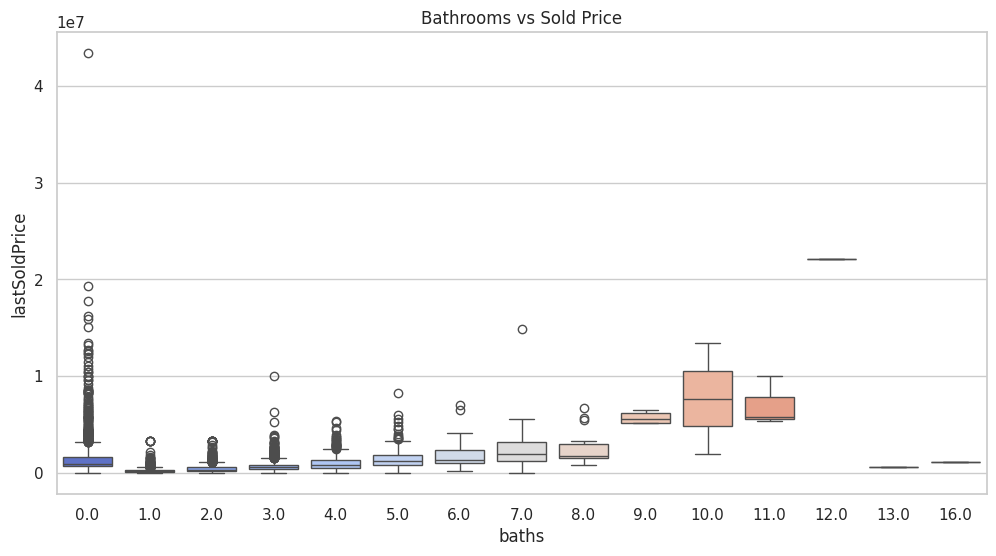

In [29]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='baths',
    y='lastSoldPrice',
    palette='coolwarm'
)

plt.title("Bathrooms vs Sold Price")
plt.show()

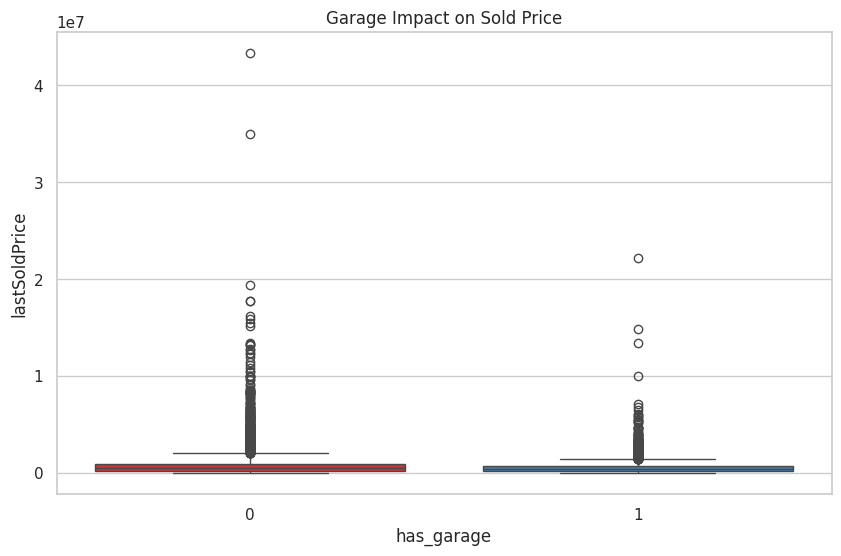

In [30]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='has_garage',
    y='lastSoldPrice',
    palette='Set1'
)

plt.title("Garage Impact on Sold Price")
plt.show()

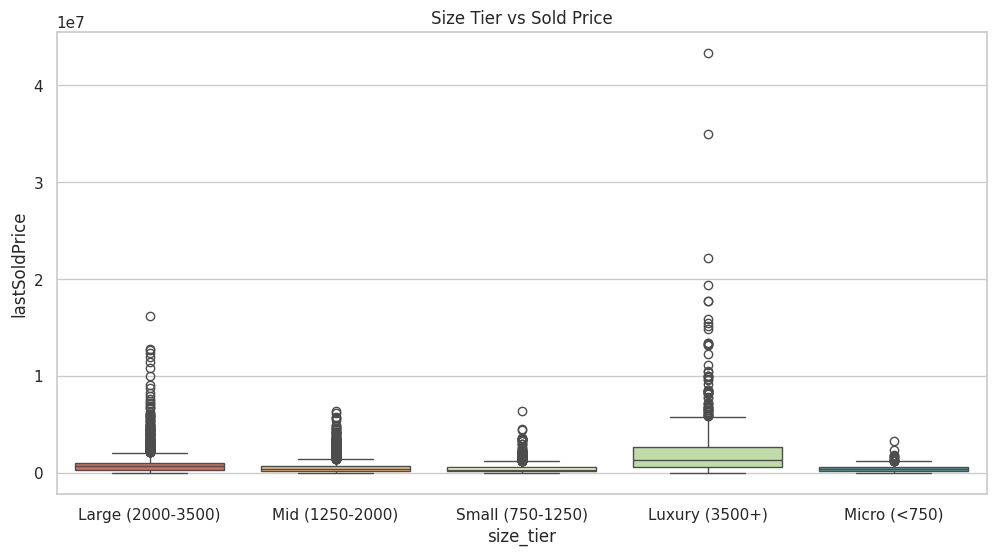

In [31]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='size_tier',
    y='lastSoldPrice',
    palette='Spectral'
)

plt.title("Size Tier vs Sold Price")
plt.show()

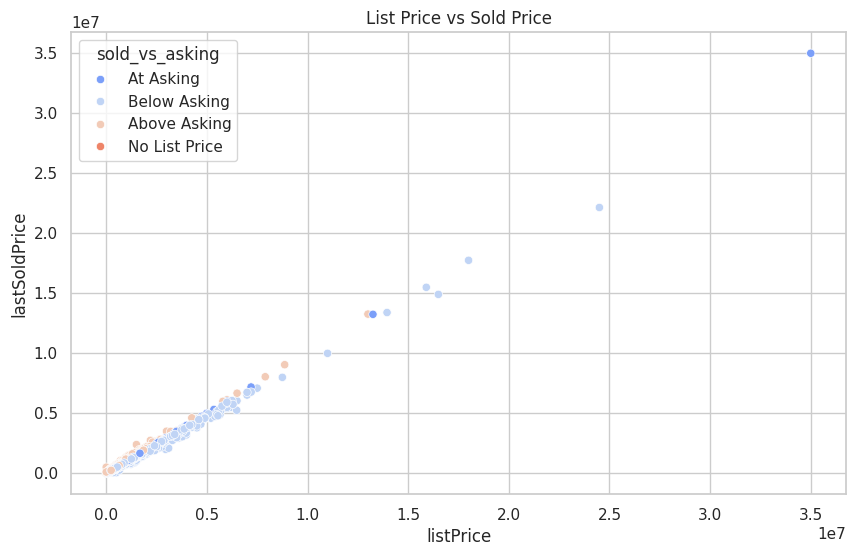

In [32]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='listPrice',
    y='lastSoldPrice',
    hue='sold_vs_asking',
    palette='coolwarm'
)

plt.title("List Price vs Sold Price")
plt.show()

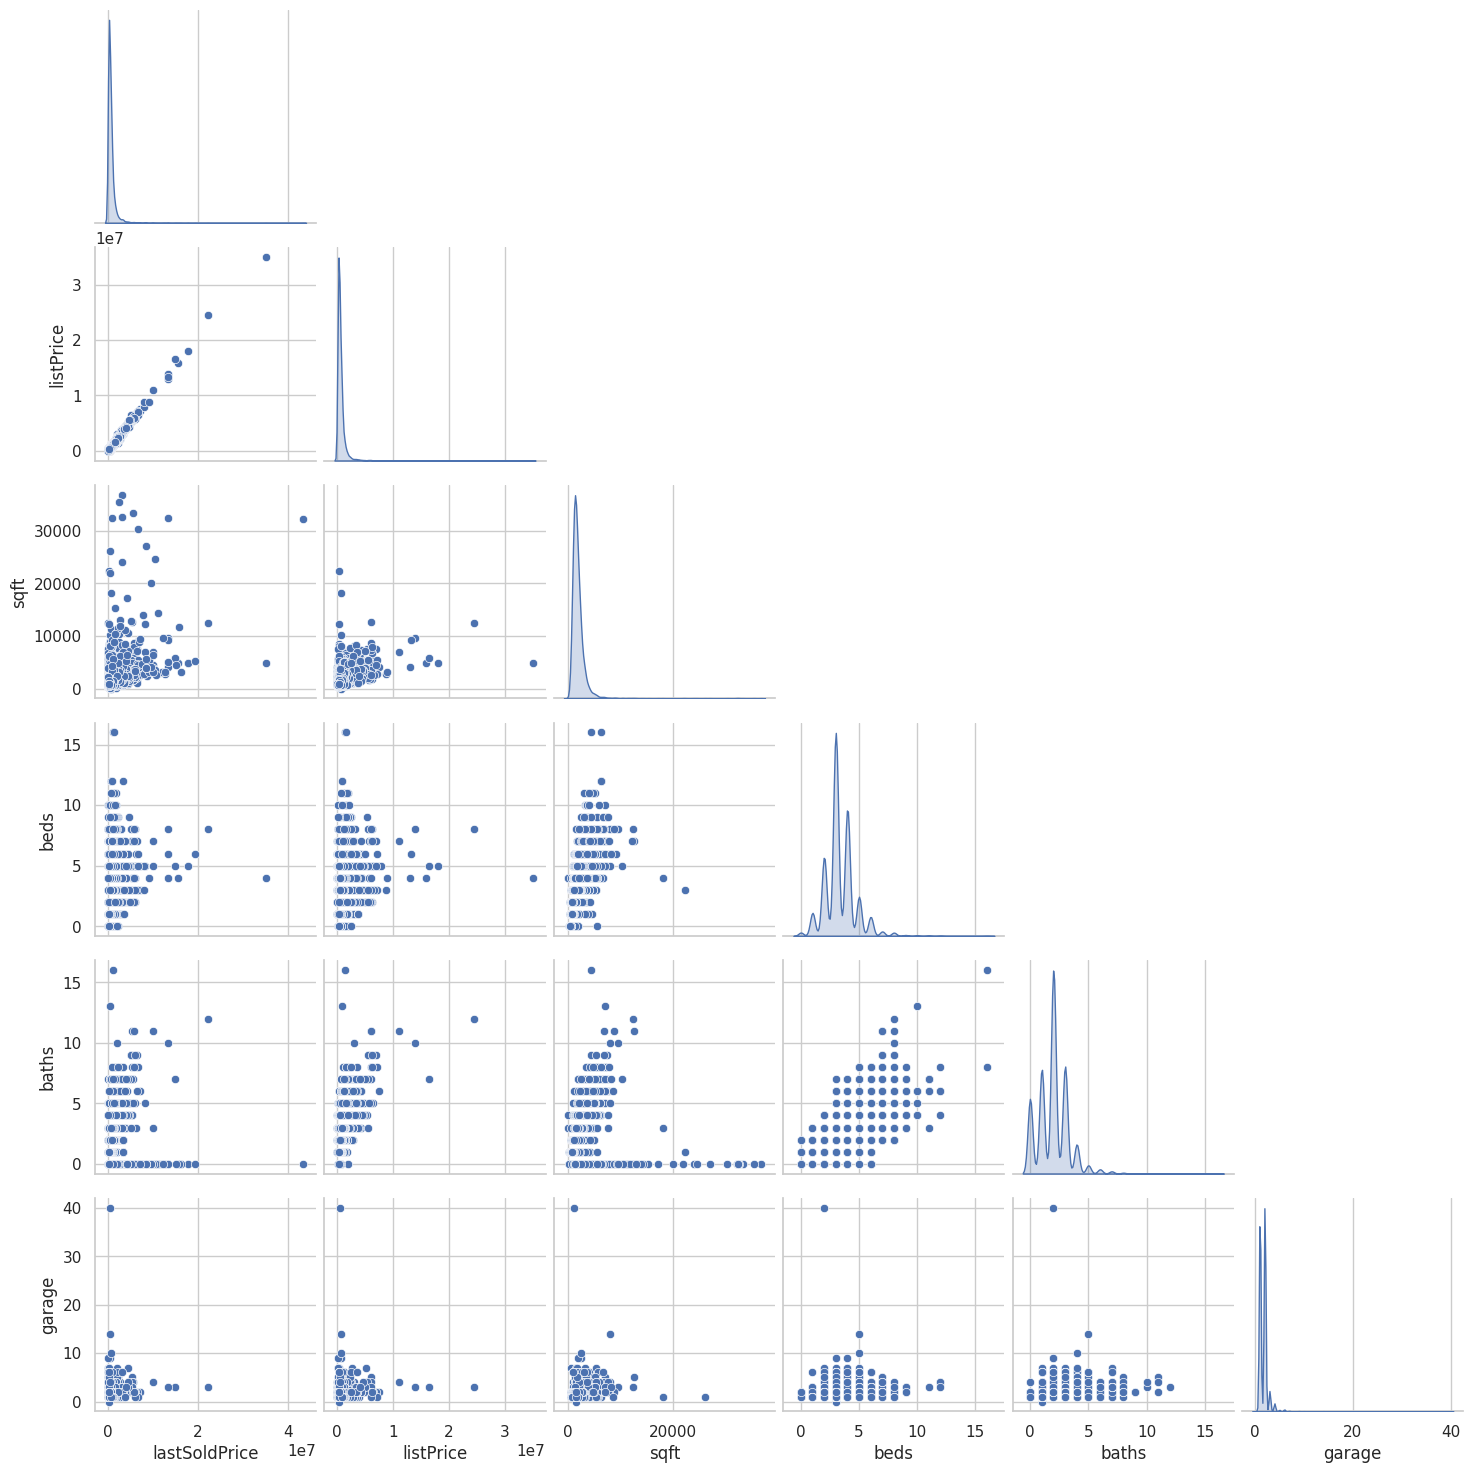

In [33]:
important_cols = [
    'lastSoldPrice',
    'listPrice',
    'sqft',
    'beds',
    'baths',
    'garage'
]

sns.pairplot(
    df[important_cols],
    corner=True,
    diag_kind='kde'
)

plt.show()

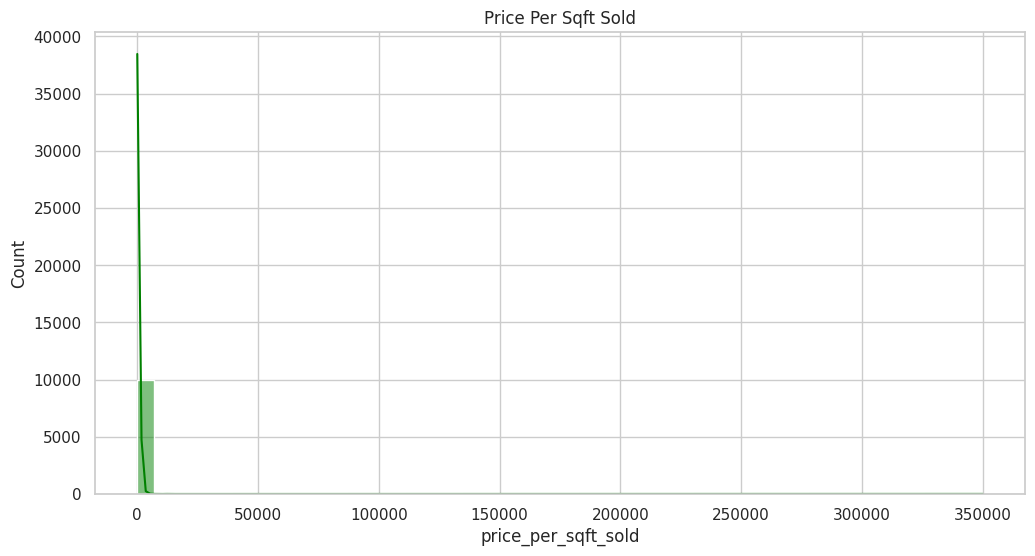

In [34]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['price_per_sqft_sold'],
    bins=50,
    color='green',
    kde=True
)

plt.title("Price Per Sqft Sold")
plt.show()

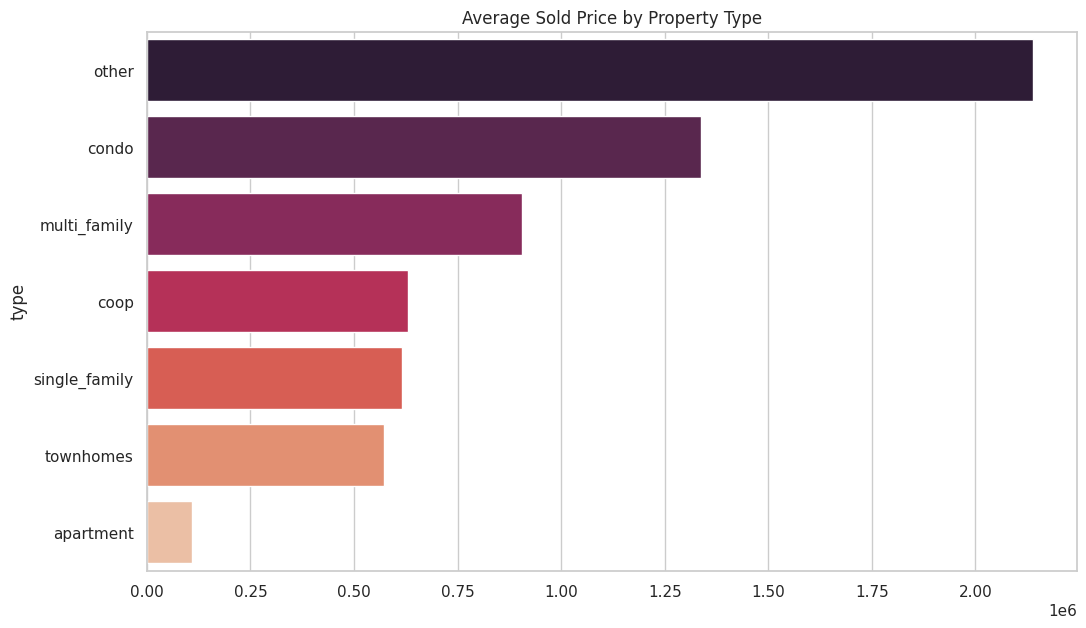

In [35]:
avg_price = (
    df.groupby('type')['lastSoldPrice']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=avg_price.values,
    y=avg_price.index,
    palette='rocket'
)

plt.title("Average Sold Price by Property Type")
plt.show()

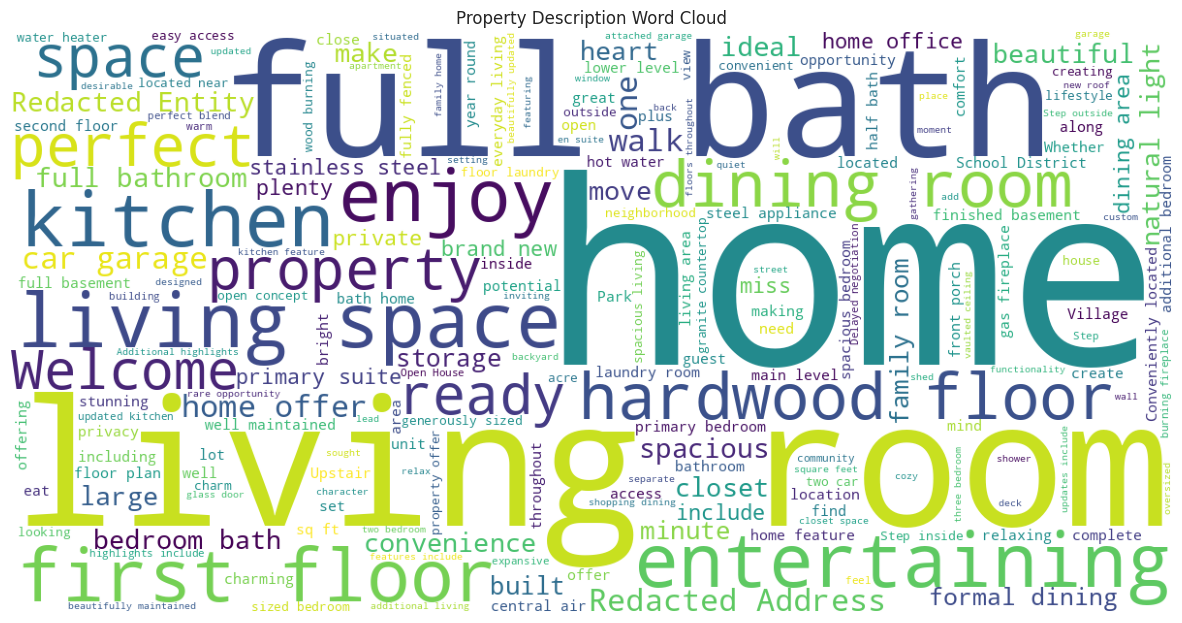

In [36]:
text = " ".join(df['text'].fillna(''))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis'
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Property Description Word Cloud")

plt.show()

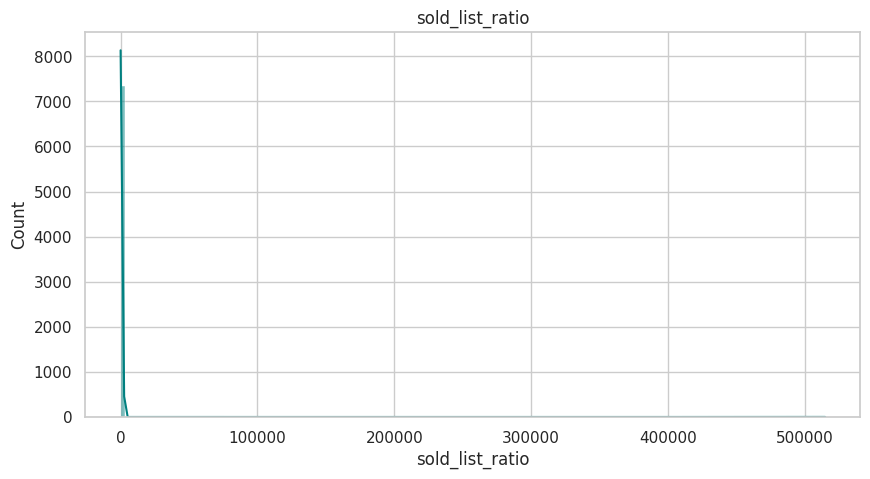

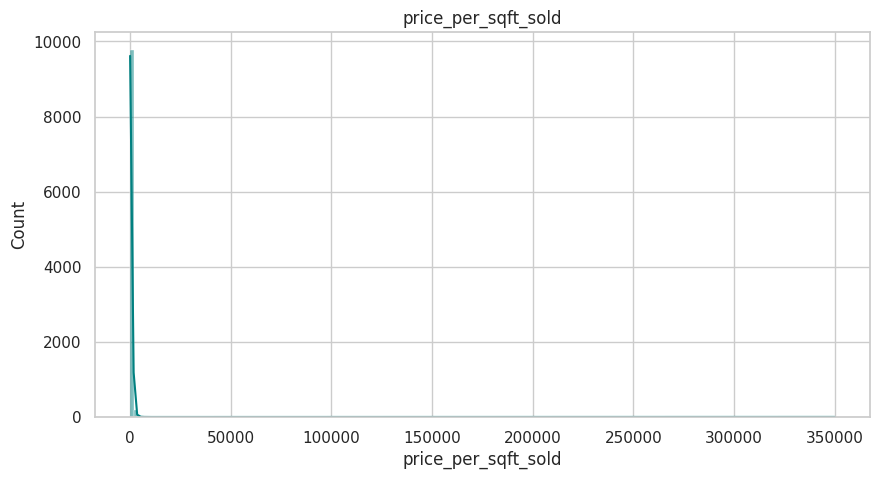

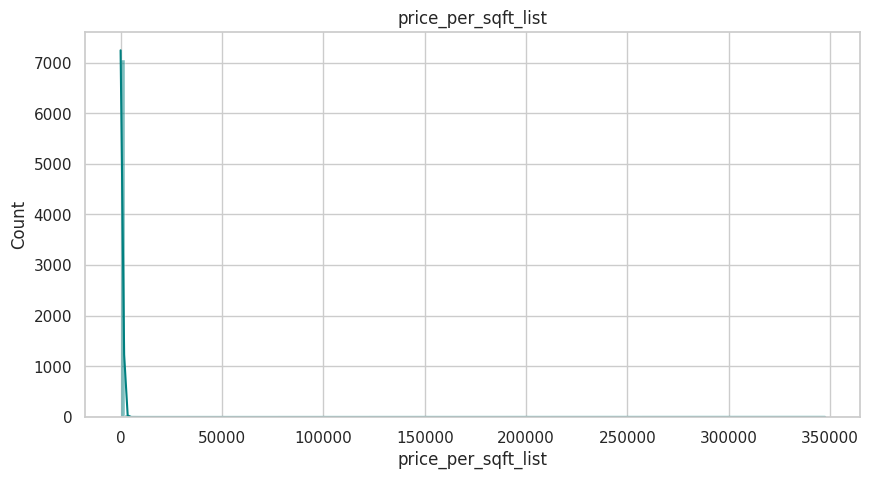

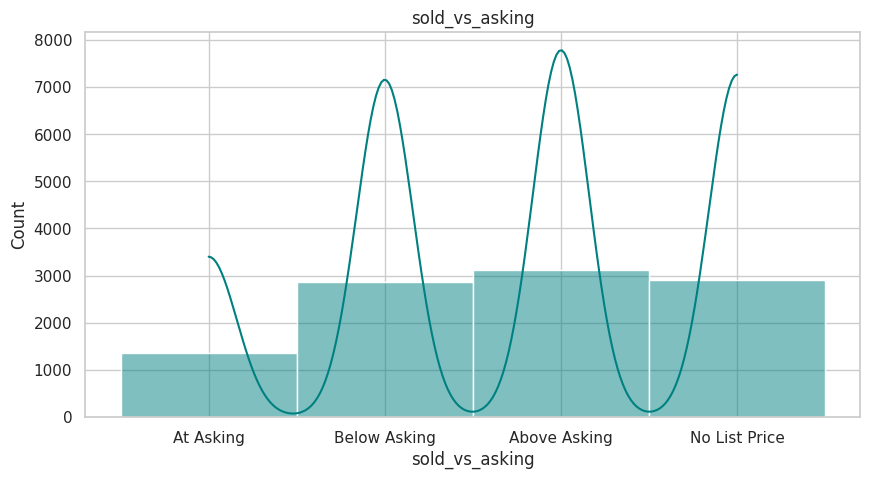

In [37]:
engineered_cols = [
    'sold_list_ratio',
    'price_per_sqft_sold',
    'price_per_sqft_list',
    'sold_vs_asking'
]

for col in engineered_cols:

    plt.figure(figsize=(10,5))

    sns.histplot(
        df[col],
        kde=True,
        color='teal'
    )

    plt.title(col)

    plt.show()

## Feature engineering

In [38]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

# Models

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

In [39]:
TARGET = "has_garage"

df = df.copy()

df = df.dropna(subset=[TARGET])

In [40]:
X = df.drop(columns=[TARGET])

y = df[TARGET]

In [41]:
le = LabelEncoder()

y = le.fit_transform(y)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8203, 22)
(2051, 22)


In [43]:
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_cols)

print("\nNumerical Features:")
print(numerical_cols)

Categorical Features:
['type', 'sub_type', 'text', 'city', 'sold_vs_asking', 'size_tier']

Numerical Features:
['listPrice', 'lastSoldPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage', 'zip_code', 'sold_list_ratio', 'price_per_sqft_sold', 'price_per_sqft_list', 'total_baths', 'has_list_price', 'sqft_available']


In [44]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_cols
        ),
        (
            "cat",
            categorical_transformer,
            categorical_cols
        )
    ]
)

In [45]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}

In [46]:
results = []

trained_models = {}

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipe.fit(X_train, y_train)

    trained_models[name] = pipe

    preds = pipe.predict(X_test)

    probs = pipe.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(
        y_test,
        preds
    )

    precision = precision_score(
        y_test,
        preds
    )

    recall = recall_score(
        y_test,
        preds
    )

    f1 = f1_score(
        y_test,
        preds
    )

    roc = roc_auc_score(
        y_test,
        probs
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

In [47]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
)

results_df = results_df.sort_values(
    "ROC_AUC",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
4    Gradient Boosting  0.883959   0.898129  0.860558  0.878942  0.960919
2        Random Forest  0.876158   0.860577  0.891434  0.875734  0.951133
6                  SVM  0.881034   0.895833  0.856574  0.875764  0.948388
3          Extra Trees  0.859581   0.824864  0.905378  0.863248  0.936529
5                  KNN  0.844954   0.855809  0.821713  0.838415  0.926653
0  Logistic Regression  0.831302   0.807477  0.860558  0.833173  0.918774
1        Decision Tree  0.862019   0.874351  0.838645  0.856126  0.861539


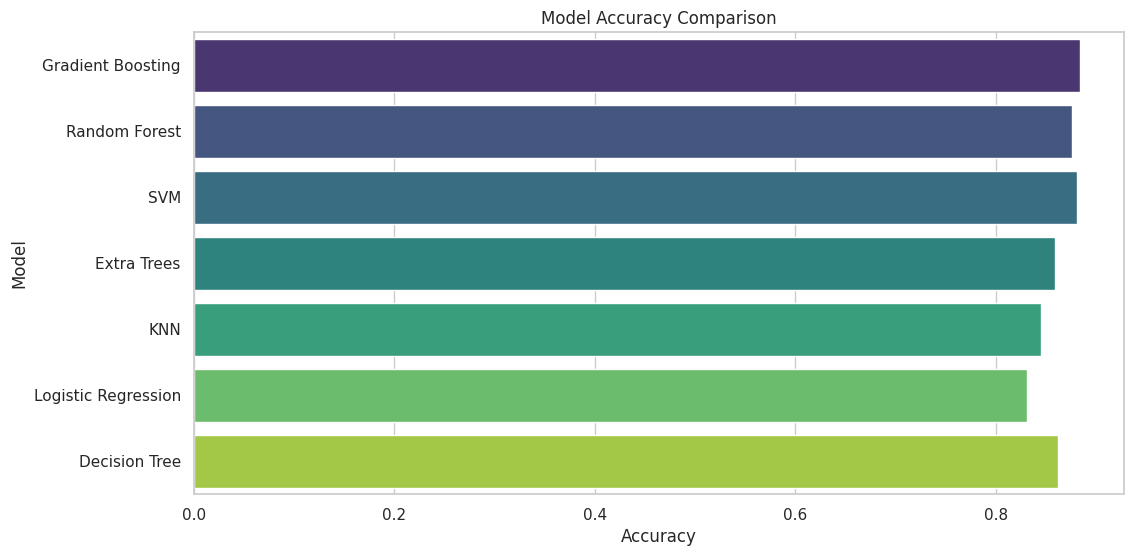

In [48]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")

plt.show()

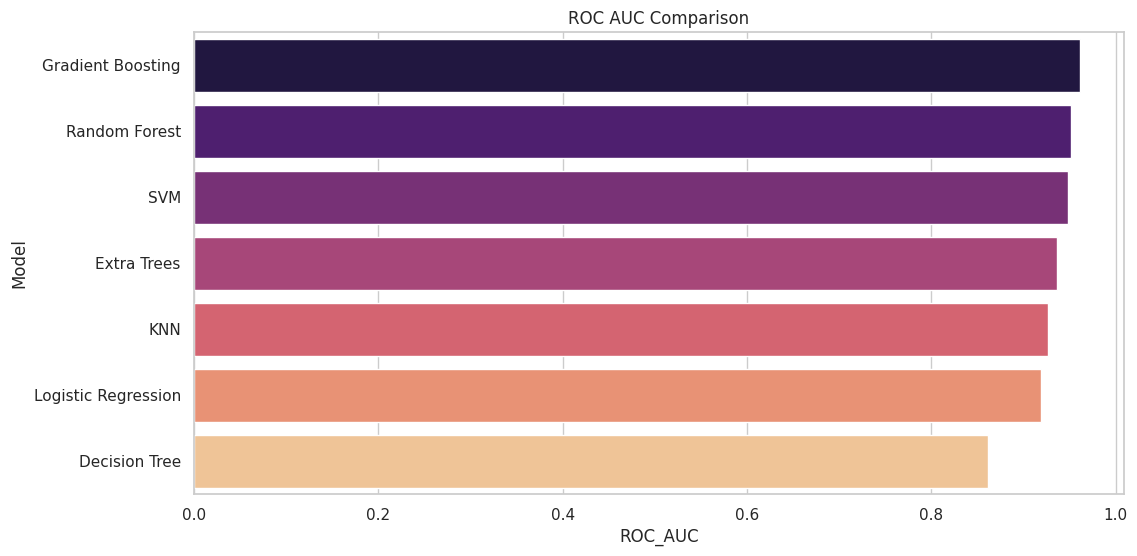

In [49]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="ROC_AUC",
    y="Model",
    palette="magma"
)

plt.title("ROC AUC Comparison")

plt.show()

In [50]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("Best Model:")
print(best_model_name)

Best Model:
Gradient Boosting


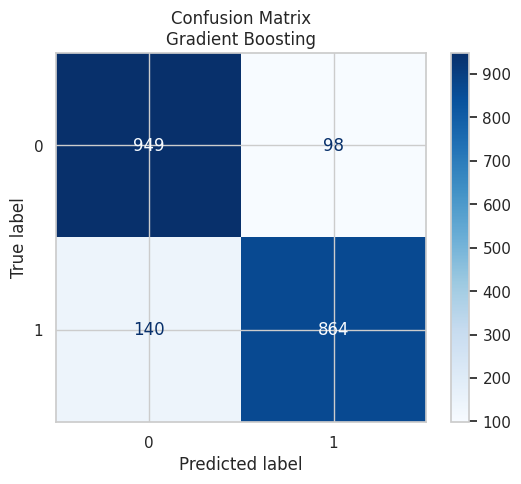

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

preds = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    cmap="Blues"
)

plt.title(
    f"Confusion Matrix\n{best_model_name}"
)

plt.show()

In [52]:
preds = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1047
           1       0.90      0.86      0.88      1004

    accuracy                           0.88      2051
   macro avg       0.88      0.88      0.88      2051
weighted avg       0.88      0.88      0.88      2051



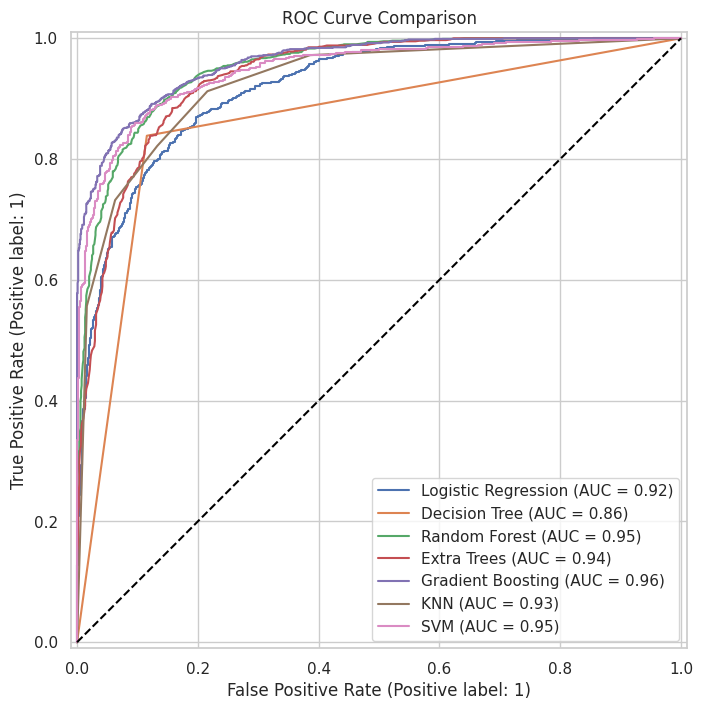

In [53]:
plt.figure(figsize=(10,8))

for name, model in trained_models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=plt.gca(),
        name=name
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.title("ROC Curve Comparison")

plt.show()

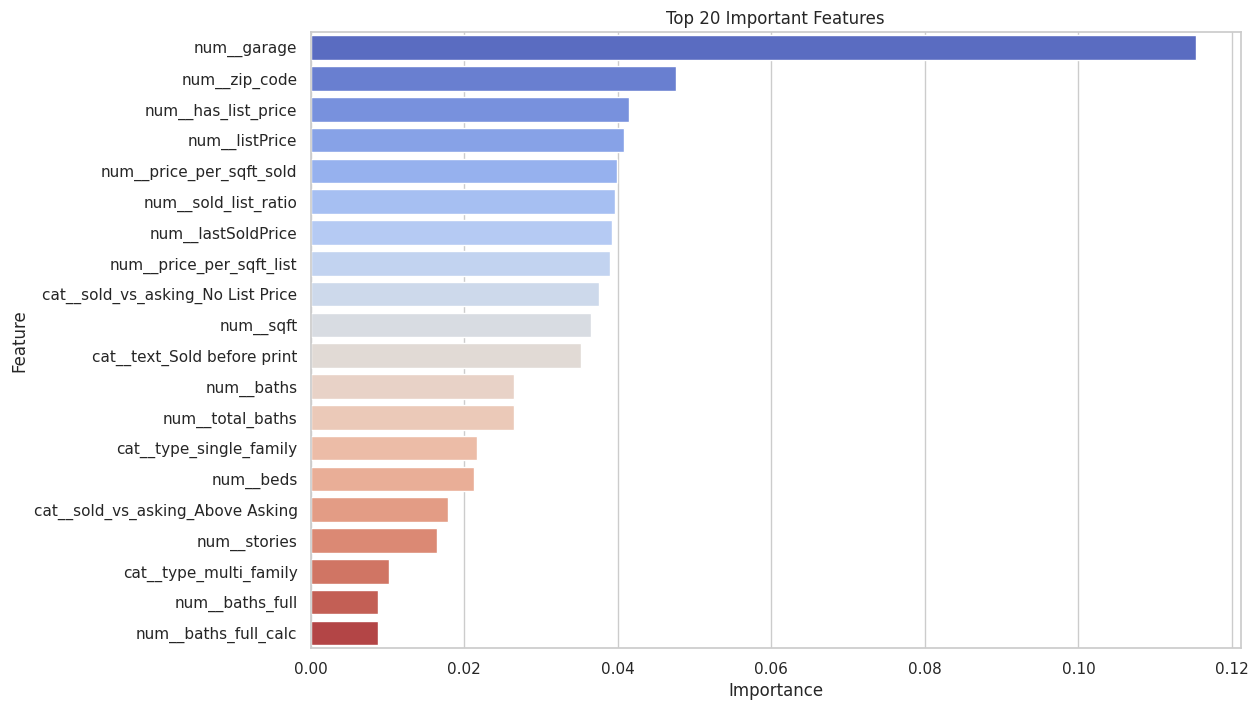

In [54]:
rf_model = trained_models["Random Forest"]

feature_names = rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = rf_model.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,
    "Importance": importances

})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    palette="coolwarm"
)

plt.title(
    "Top 20 Important Features"
)

plt.show()

## Thank you...pls upvote!!!!!!!!!!!!!!